In [53]:
# ============================================
# Cell 1 — Import Libraries
# ============================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt

import joblib

In [54]:
# ============================================
# Cell 2 — Load Dataset
# ============================================

# Replace with your dataset filename
df = pd.read_csv("Dataset/dataset-eye_blink_data_10k.csv")

# Show first rows
df.head()

,Blink_Rate,Blink_Duration,Incomplete_Blink_Ratio,Class_Label
0,22.47,0.17,0.32,Normal
1,17.39,0.21,0.31,Normal
2,23.68,0.18,0.06,Normal
3,30.68,0.26,0.37,Fatigue_Dryness
4,16.63,0.39,0.00,Normal


In [55]:
# ============================================
# Cell 3 — Define Features and Labels
# ============================================

X = df[[
    "Blink_Rate",
    "Blink_Duration",
    "Incomplete_Blink_Ratio"
]]

y = df["Class_Label"]

print(X.head())
print(y.head())

   Blink_Rate  Blink_Duration  Incomplete_Blink_Ratio
0       22.47            0.17                    0.32
1       17.39            0.21                    0.31
2       23.68            0.18                    0.06
3       30.68            0.26                    0.37
4       16.63            0.39                    0.00
0             Normal
1             Normal
2             Normal
3    Fatigue_Dryness
4             Normal
Name: Class_Label, dtype: object


In [56]:
try:
    df
except NameError:
    df = pd.read_csv("Dataset/dataset-eye_blink_data_10k.csv")

# Required columns check
cols = ["Blink_Rate", "Blink_Duration", "Incomplete_Blink_Ratio"]
for c in cols:
    if c not in df.columns:
        raise ValueError(f"Missing column: {c}")

# Normalize (0-1 scaling)
df_norm = df.copy()
for c in cols:
    df_norm[c] = (df[c] - df[c].min()) / (df[c].max() - df[c].min() + 1e-8)

# Weighted score (40% / 35% / 25%)
df["Weighted_Score"] = (
    0.40 * df_norm["Blink_Rate"] +
    0.35 * df_norm["Blink_Duration"] +
    0.25 * df_norm["Incomplete_Blink_Ratio"]
)

print("✅ Weighting completed successfully!")
df[cols + ["Weighted_Score"]].head()

✅ Weighting completed successfully!


,Blink_Rate,Blink_Duration,Incomplete_Blink_Ratio,Weighted_Score
0,22.47,0.17,0.32,0.328191
1,17.39,0.21,0.31,0.302069
2,23.68,0.18,0.06,0.276917
3,30.68,0.26,0.37,0.448345
4,16.63,0.39,0.00,0.298339


In [57]:
# ============================================
# Cell 4 — Encode Labels
# ============================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Label Encoding:\n")

for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} --> {i}")

Label Encoding:

Fatigue_Dryness --> 0
Normal --> 1


In [58]:
# ============================================
# Cell 5 — Train Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 8000
Testing Samples: 2000


In [59]:
# ============================================
# Cell 6 — Create Random Forest Model
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
# ============================================
# Cell 7 — Train Model
# ============================================

rf_model.fit(X_train, y_train)

print("Model Training Completed.")

Model Training Completed.


In [61]:
# ============================================
# Cell 8 — Prediction
# ============================================

y_pred = rf_model.predict(X_test)

print(y_pred[:10])

[0 1 0 0 0 0 0 0 0 0]


In [62]:
# ============================================
# Cell 9 — Accuracy
# ============================================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 98.65 %


In [63]:
# ============================================
# Cell 10 — Classification Report
# ============================================

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

                 precision    recall  f1-score   support

Fatigue_Dryness       1.00      0.97      0.99       957
         Normal       0.97      1.00      0.99      1043

       accuracy                           0.99      2000
      macro avg       0.99      0.99      0.99      2000
   weighted avg       0.99      0.99      0.99      2000



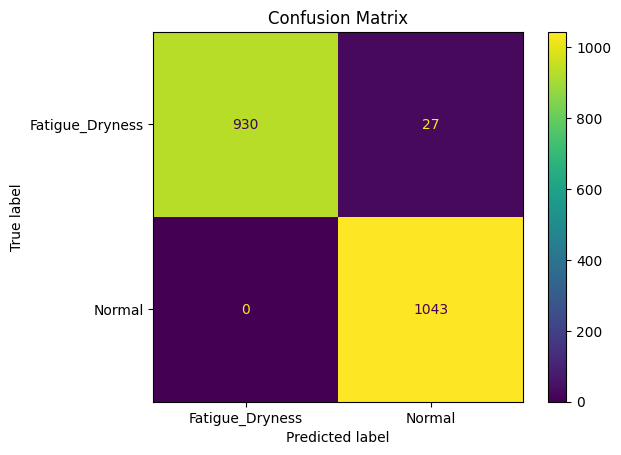

In [64]:
# ============================================
# Cell 11 — Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

In [65]:
# ============================================
# Cell 12 — Feature Importance
# ============================================

feature_importance = rf_model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": feature_importance
})

importance_df["Display_Order"] = importance_df["Feature"].map({
    "Blink_Rate": 0,
    "Blink_Duration": 1,
    "Incomplete_Blink_Ratio": 2
})

importance_df = importance_df.sort_values(
    by="Display_Order"
).drop(columns=["Display_Order"])

importance_df

,Feature,Importance
0,Blink_Rate,0.243177
1,Blink_Duration,0.325485
2,Incomplete_Blink_Ratio,0.431338


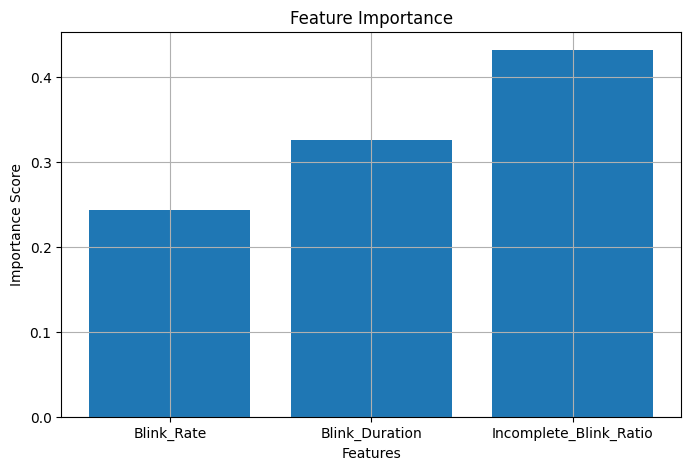

In [66]:
# ============================================
# Cell 13 — Plot Feature Importance
# ============================================

plt.figure(figsize=(8, 5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.grid(True)

plt.show()

In [67]:
# ============================================
# Cell 14 — Test New Sample
# ============================================

new_sample = pd.DataFrame({
    "Blink_Rate": [30],
    "Blink_Duration": [0.45],
    "Incomplete_Blink_Ratio": [0.60]
})

prediction = rf_model.predict(new_sample)

predicted_class = label_encoder.inverse_transform(prediction)

print("Prediction:", predicted_class[0])

Prediction: Fatigue_Dryness


In [68]:
# ============================================
# Cell 15 — Save Model
# ============================================

joblib.dump(
    rf_model,
    "blink_random_forest_model.pkl"
)

print("Model Saved Successfully.")


Model Saved Successfully.
